In [1]:
from astropy.io import fits

import numpy as np
import matplotlib.pyplot as plt

from scipy.io import readsav
from scipy.optimize import curve_fit
from sklearn.decomposition import PCA

from tqdm import tqdm

import tools as t

## Extract data

In [2]:
# load files
path_data = '../data/sim_series/'
N_files = 19  # 19 temporal series, need to check file N°20
data_spectra = []
data_rv = []
for i in range(1, N_files+1):
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
    data_rv.append(readsav(path_data + f'res_rv_bis_6173_lionel_tau1_scaling1_sansrot_serie{i}.sav'))
data_spectra = np.array(data_spectra)
data_rv = np.array(data_rv)
data_rv[0].keys()

dict_keys(['rv_gauss', 'rv_correl', 'rv_deriv', 'xbiss', 'ybiss', 'l_true', 'lambd', 'flux_moy'])

In [3]:
data_spectra.shape

(19, 3686, 122)

data_spectra[ i ]: matrix with 3686 spectra of 122 elements each \
data_rv[ i ]: dictionary

In [4]:
c = 3e8  # m/s
# extract data
wl = np.array(data_rv[0]['lambd'])  # same wavelength grid for all time series (verified)
times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series
rv_ccf = []
template = []
for i in range(N_files):
    rv_ccf.append(data_rv[i]['rv_correl'])
    template.append(data_rv[i]['flux_moy'])
wl = np.array(wl)
rv_ccf = np.array(rv_ccf)
template = np.array(template)

## Calculate RV by template matching

In [5]:
# template matching: calculate the mean spectrum
mean_spec = np.array([np.mean(i, axis=0) for i in data_spectra])  # list of 19 mean spectra
d_S0 = np.array([np.gradient(i, wl) for i in mean_spec])  # derivative of the mean spectra

In [6]:
# calculate radial velocity by template matching
C_0 = 1000
rv_tm = []
for j in range(N_files):  # iterate over each time series
    rv_j = []
    for k in range(len(times)):  # for each spectrum
        rv_j.append(t.calculate_rv(wl, mean_spec[j], data_spectra[j][k], C_0))
    rv_tm.append(np.array(rv_j))
rv_tm = np.array(rv_tm)

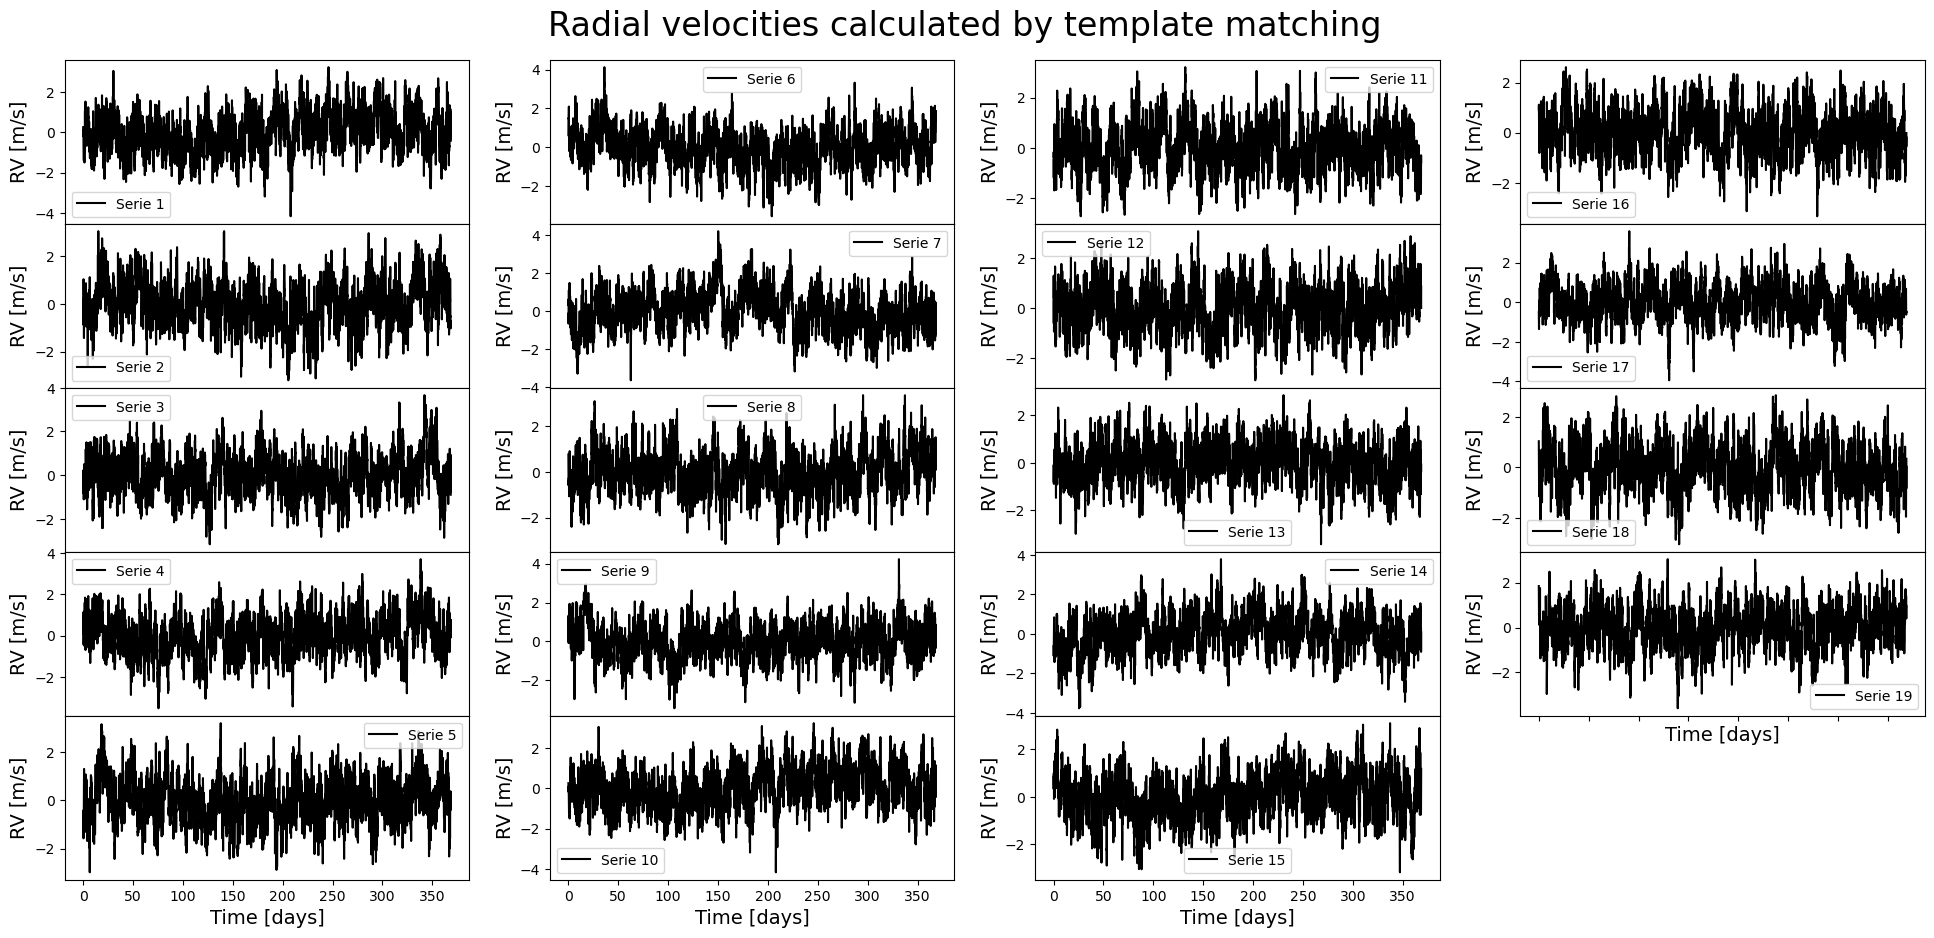

In [7]:
# plot RV
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('Radial velocities calculated by template matching', size=24)

r = 0  # row counter
k = -1  # column counter

for i in range(N_files):  # iterate over the 19 time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][k].set_xlabel('Time [days]', size=14)
    axs[r][k].plot(times, rv_tm[i], color='k', label=f'Serie {i+1}')
    axs[r][k].set_ylabel('RV [m/s]', size=14)
    axs[r][k].legend()
    r += 1  # advance to the next row

fig.delaxes(axs[-1][-1])  # take out extra subplot
axs[-2][-1].set_xlabel('Time [days]', size=14)

#xticks = axs[-1][-2].get_xticks()[1:]
#axs[-2][-1].set_xticks(xticks)
#axs[-2][-1].set_xticklabels([str(int(i)) for i in xticks])

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

## Calculate RV by CCF

In [8]:
c = 3e8
delta_vel = np.linspace(-5, 5, 201)  # define RV grid
lambda_vr = np.array([t.calculate_lambda_vr(wl, v) for v in delta_vel])  # wavelength grid for each v

In [9]:
# interpolate flux over lambda_vr to fit the originl wavelength grid (wl)
shifted_mask = []  # each element is a list of shifted masks, corresponding to each delta_vel
for i in range(N_files):
    sm_i = []  # shifted mask corresponding to the time series i
    for wl_grid in lambda_vr:  # iterate over wavelength grids
        sm_i.append(np.interp(wl, wl_grid, mean_spec[i]))
    shifted_mask.append(np.array(sm_i))
shifted_mask = np.array(shifted_mask)

In [10]:
# calculate CCF between each measured spectrum and the reference spectrum
ccf = []
for k in tqdm(range(N_files)):  # iterate over each time series
    ccf_i = []
    for j in range(len(times)):  # iterate over measured (simulated) spectra
        ccf_i.append(np.array(
                [sum(t.cross_correlate(data_spectra[k][j], shifted_mask[k][i])) for i in range(len(delta_vel))]  # CCF
                ))
    ccf.append(np.array(ccf_i))
ccf = np.array(ccf)

100%|██████████| 19/19 [03:51<00:00, 12.17s/it]


In [11]:
# fit a gaussian to each CCF
params = []
models = []
for i in tqdm(range(N_files)):  # each i is the index of a list of CCFs
    ccf_i = ccf[i]
    params_i = []
    model_i  = []
    for j in range(len(ccf_i)):  # iterate over the indices of the CCFs (each iteration is a CCF)
        params_j, _ = curve_fit(t.gaussian, delta_vel, ccf_i[j], p0=[max(ccf_i[j])- min(ccf_i[j]), 0, np.std(delta_vel), np.max(ccf_i[j])])  # fit a gaussian to the CCF and save the parameters
        model_j = t.gaussian(delta_vel, params_j[0], params_j[1], params_j[2], params_j[3])  # calculate the model using the obtained parameters
        params_i.append(params_j)  # save parameters
        model_i.append(model_j)  # save models
    params.append(params_i)  # save parameters
    models.append(model_i)  # save models
params = np.array(params)
models = np.array(models)
mean_vels = np.array([i[:, 1] for i in params])  # recover the position of the peak of each gaussian

  0%|          | 0/19 [00:00<?, ?it/s]/tmp/ipykernel_6691/1389857413.py:9: OptimizeWarning: Covariance of the parameters could not be estimated
  params_j, _ = curve_fit(t.gaussian, delta_vel, ccf_i[j], p0=[max(ccf_i[j])- min(ccf_i[j]), 0, np.std(delta_vel), np.max(ccf_i[j])])  # fit a gaussian to the CCF and save the parameters
100%|██████████| 19/19 [01:30<00:00,  4.78s/it]


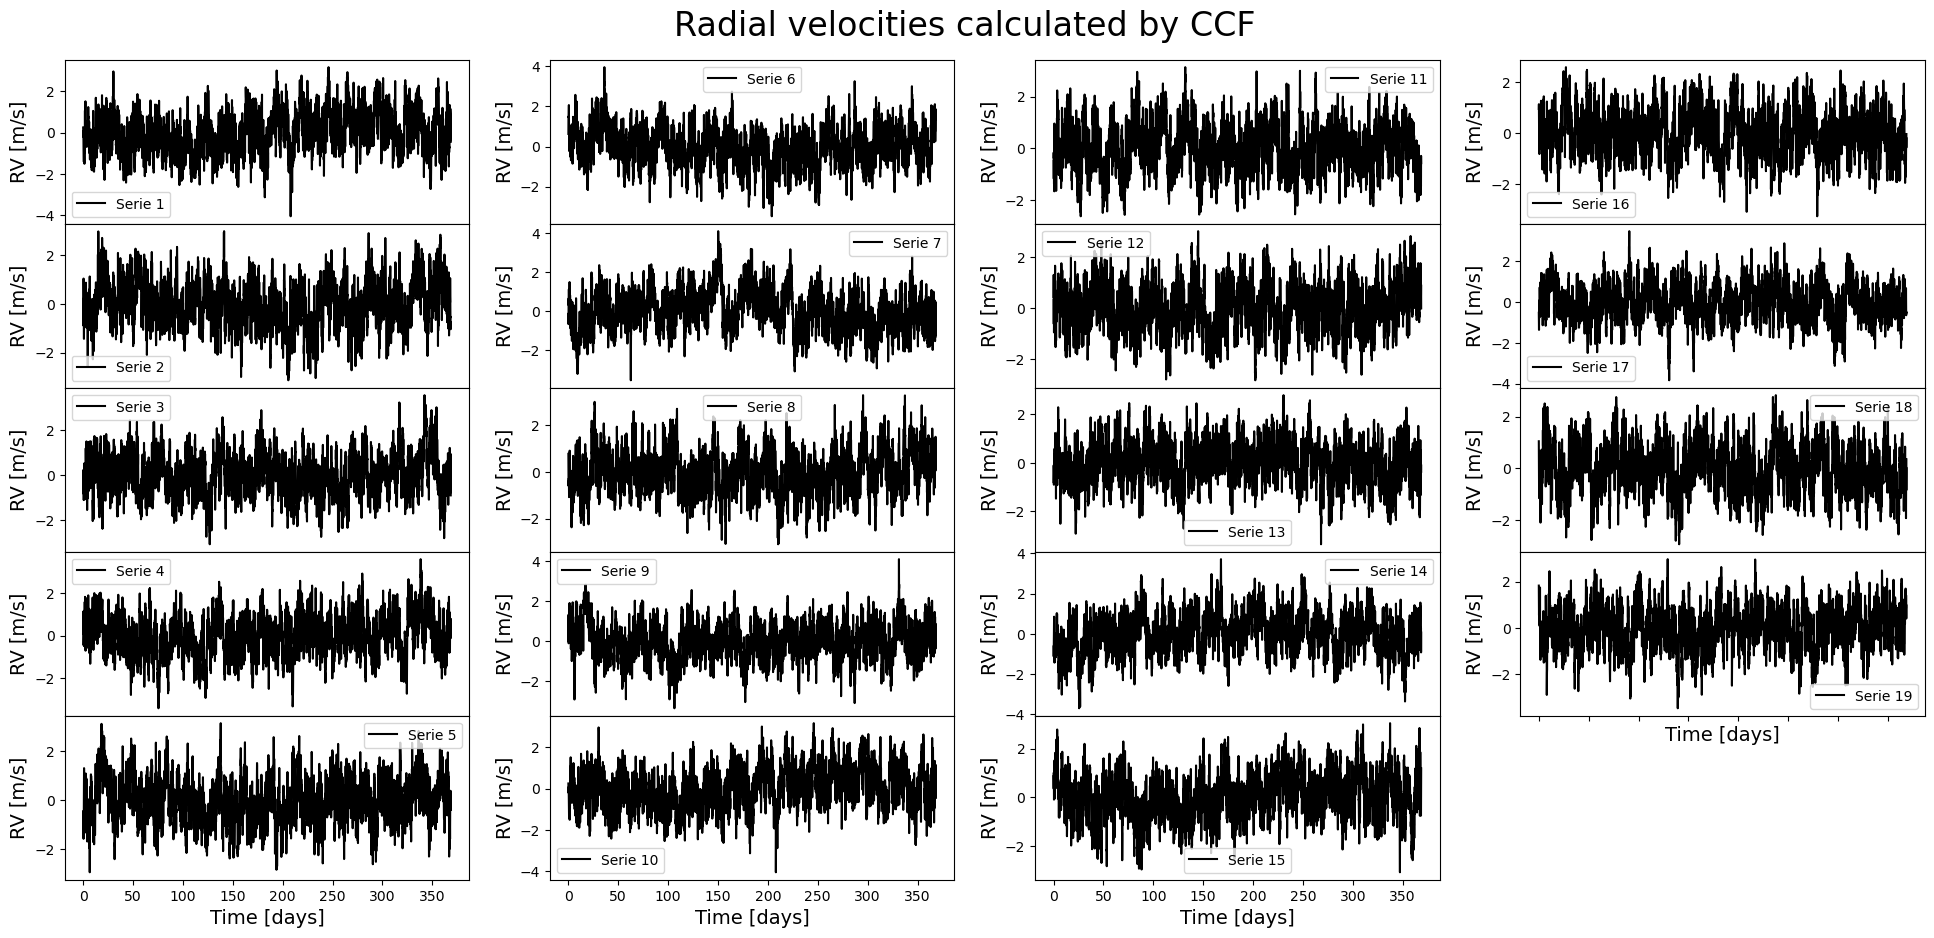

In [12]:
# plot RV
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('Radial velocities calculated by CCF', size=24)

r = 0
k = -1
for i in range(N_files):  # iterate over the 19 time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][k].set_xlabel('Time [days]', size=14)
    axs[r][k].plot(times, mean_vels[i], color='k', label=f'Serie {i+1}')
    axs[r][k].set_ylabel('RV [m/s]', size=14)
    axs[r][k].legend()
    r += 1  # advance to the next row

fig.delaxes(axs[-1][-1])  # take out extra subplot
axs[-2][-1].set_xlabel('Time [days]', size=14)

#xticks = axs[-1][-2].get_xticks()[1:]
#axs[-2][-1].set_xticks(xticks)
#axs[-2][-1].set_xticklabels([str(int(i)) for i in xticks])

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

In [13]:
rv_ccfE = mean_vels

## RV Periodograms

In [ ]:
# calculate RV periodograms
dt = times[1] - times[0]  # delta time in days
dt_sec = dt * 86400  # delta time in seconds
norm = len(times) * dt_sec  # same timestep for all techniques, so same normalization by total time (N * dt)

# power spectrum
ffts = []  # FT of each temporal series
power_specs = []  # PS of each temporal serie

for i in range(N_files):
    #sp_ccf = np.fft.fft(rv_ccf[i]) * dt_sec  # of RV calculated by CCF (Nadège)
    #power_ccf = np.abs(sp_ccf)**2 / norm

    #sp_tm = np.fft.fft(rv_tm[i]) * dt_sec  # of RV calculated by TM
    #power_tm = np.abs(sp_tm)**2 / norm

    sp_ccfE = np.fft.fft(rv_ccfE[i]) * dt_sec  # of RV calculated by CCF (Etienne)
    ffts.append(sp_ccfE)
    power_specs.append(np.abs(sp_ccfE)**2 / norm)

# calculate frequencies
freq_days = np.fft.fftfreq(len(times), dt)  # frequency in days^-1 same for all power spectra
freq_hz   = freq_days / 86400  # frequency in Hz
mask = freq_days > 0

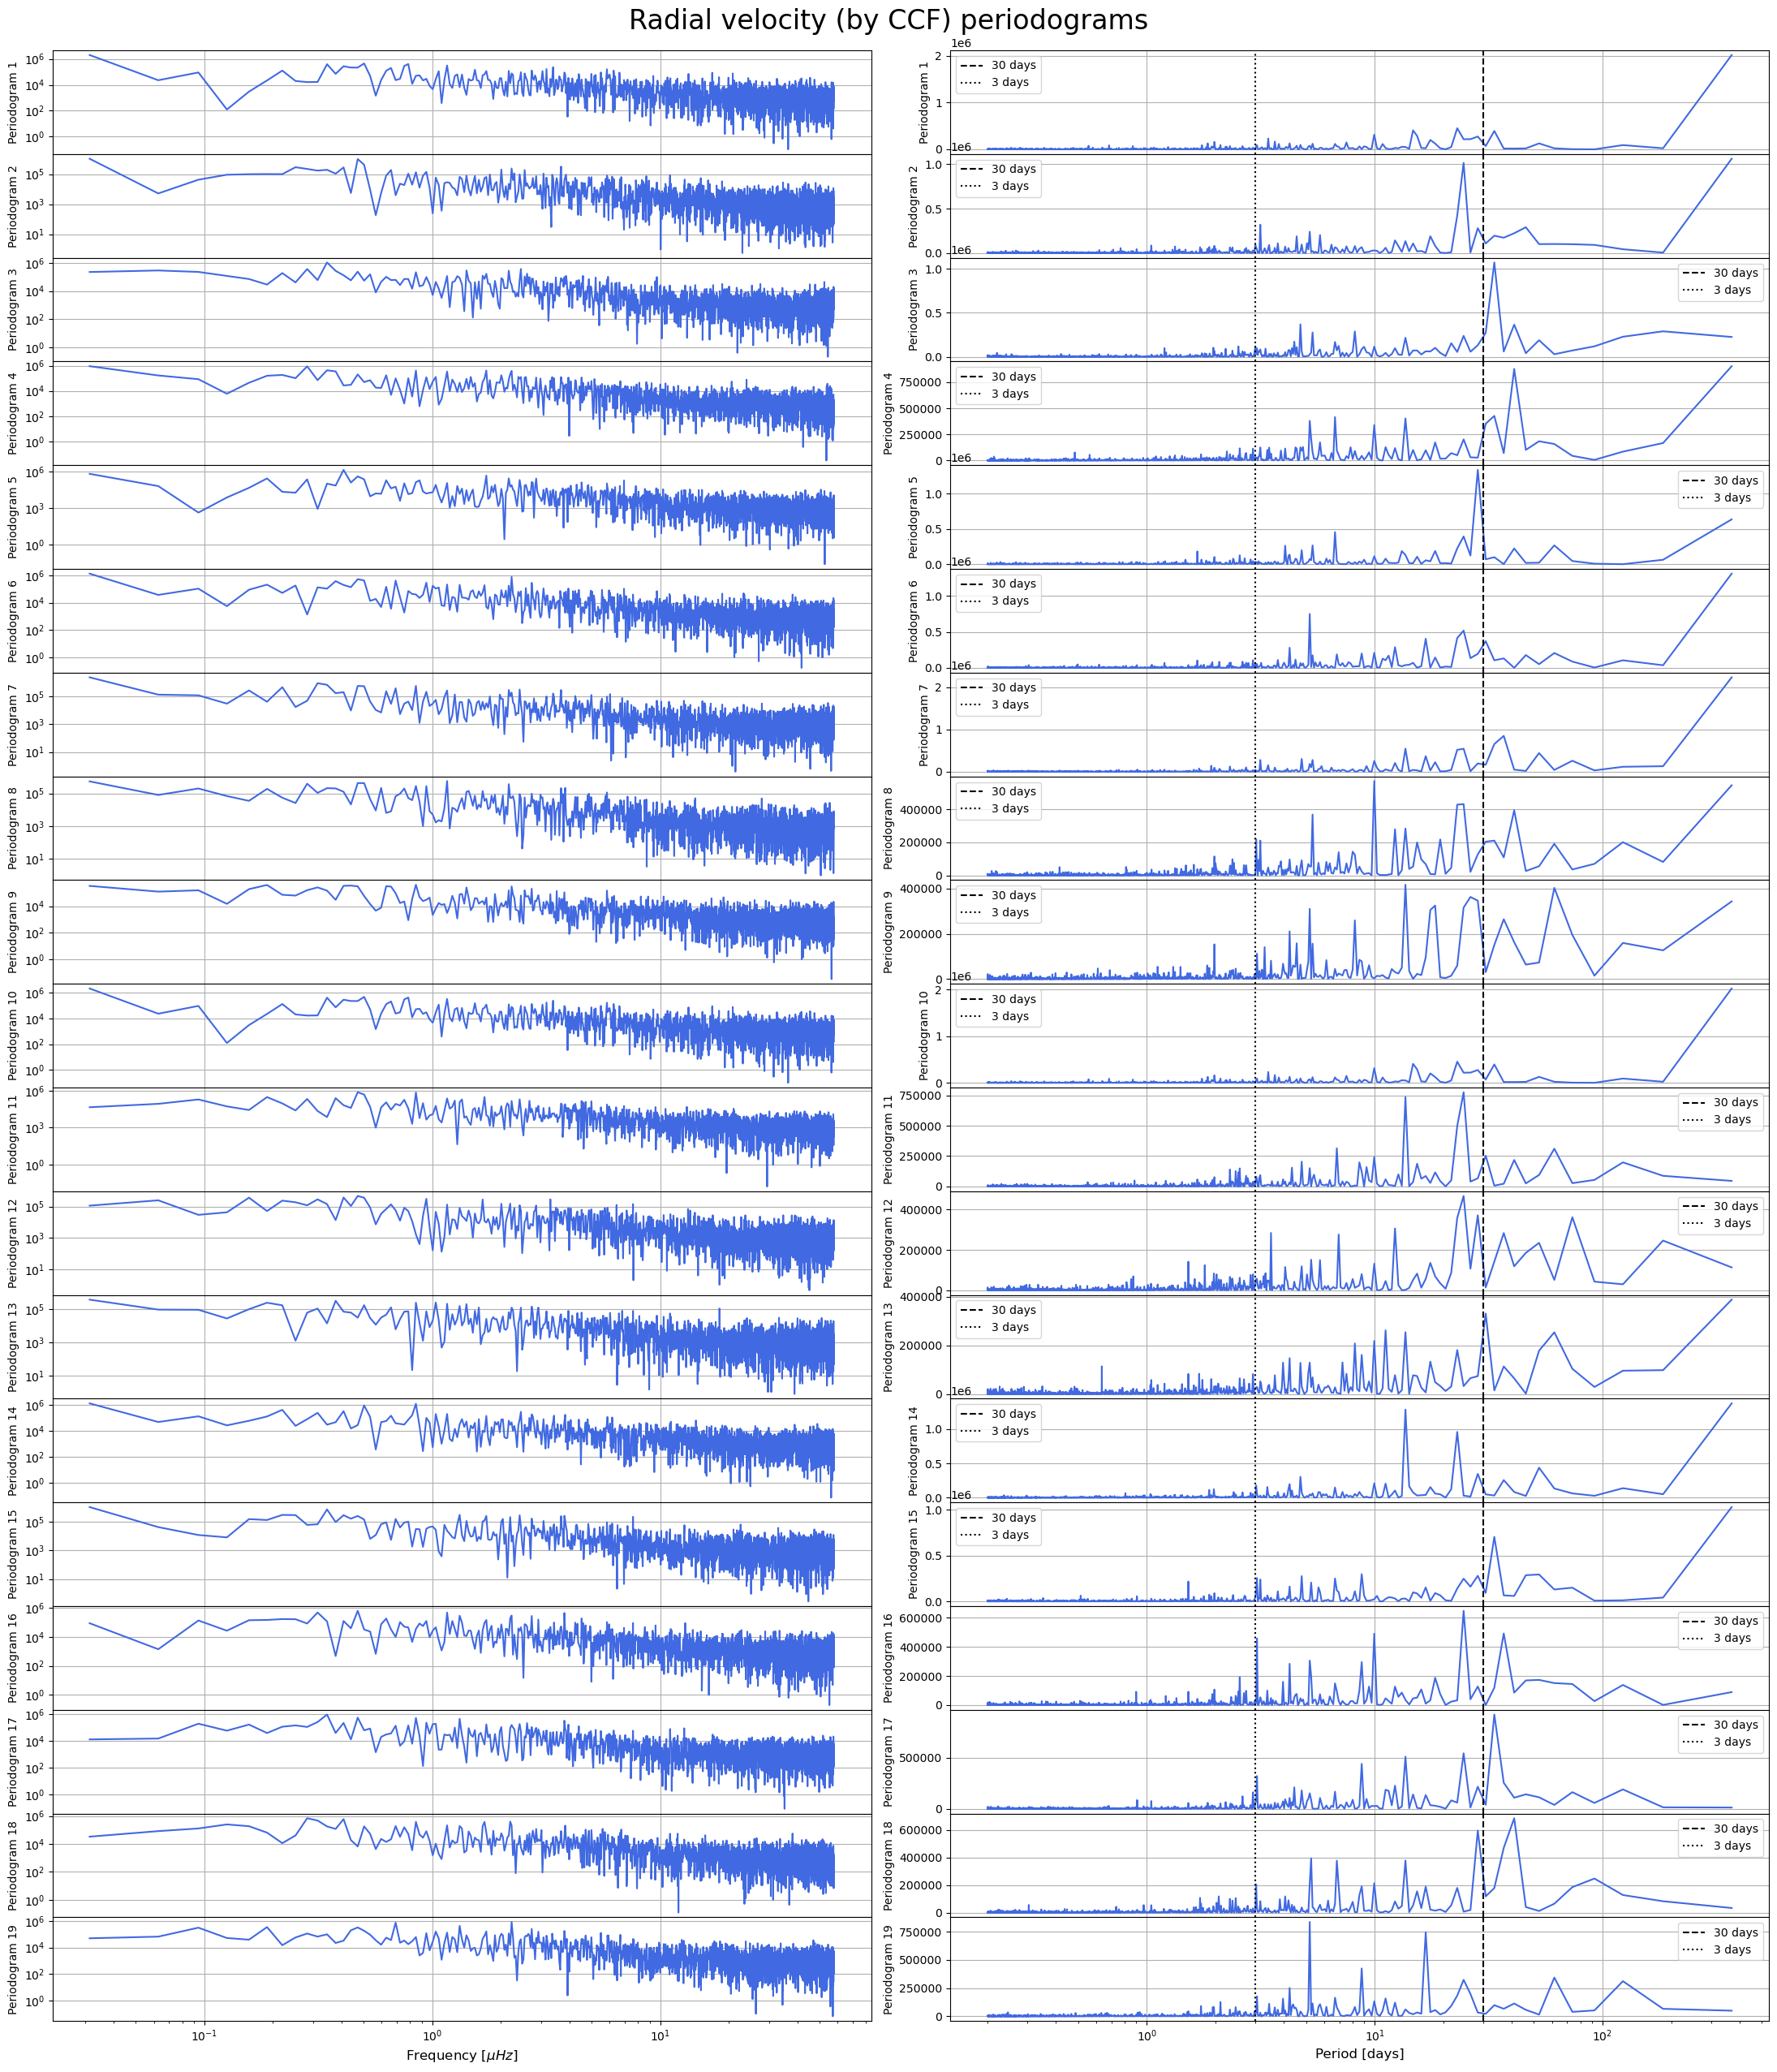

In [25]:
# plot RV (calculated by CCF by Etienne) periodograms
fig, axs = plt.subplots(19, 2, figsize=(22, 26), sharex='col')
fig.suptitle('Radial velocity (by CCF) periodograms', size=24)

for i in range(N_files):
    # Frequency periodogram
    axs[i][0].plot(freq_hz[mask] * 10**6, power_specs[i][mask], color='royalblue')
    axs[i][0].set_yscale('log')
    axs[i][0].set_xscale('log')
    axs[i][0].set_ylabel(f'Periodogram {i+1}', size=10)
    axs[i][0].set_xlabel(r'Frequency [$\mu Hz$]', size=12)
    axs[i][0].grid()

    # Periodogram
    axs[i][1].plot(1 / freq_days[mask], power_specs[i][mask], color='royalblue')
    axs[i][1].axvline(30, color='k', linestyle='--', label='30 days')
    axs[i][1].axvline(3, color='k', linestyle=':', label='3 days')
    axs[i][1].set_xscale('log')
    axs[i][1].set_xlabel('Period [days]', size=12)
    axs[i][1].set_ylabel(f'Periodogram {i+1}', size=10)
    axs[i][1].grid()
    axs[i][1].legend()

fig.tight_layout()
plt.subplots_adjust(hspace=0, top=.96)
plt.show()

In [36]:
# split time series into chunks
n_chunks = 19
time_chunks = np.array_split(times, n_chunks)
ccf_chunks  = [np.array_split(i, n_chunks) for i in rv_ccfE]  # list of N_files lists of chunks
norm_mean = len(time_chunks[0]) * dt_sec  # normalization by total time (N * dt)

# do FT for each chunk
pg_chunked = []  # list of N_files lists (one for each time series) of n_chunks dictionaries (one for each chunk)
for i in range(N_files):
    periodograms = {}
    for j in range(n_chunks):  # iterate over chunk index
        # power spectrum
        sp_ccf_j = np.fft.fft(ccf_chunks[i][j]) * dt_sec  # apply FFT to the chunk j
        power_ccf_j = np.abs(sp_ccf_j)**2 / norm_mean  # calculate normalized power

        # calculate frequencies
        freq_j = np.fft.fftfreq(len(ccf_chunks[i][j]), dt)  # dt stays the same, so the frequencies are the same for all periodograms
        mask_j = freq_j > 0  # same mask for all periodograms

        periodograms[j] = [sp_ccf_j, power_ccf_j, freq_j, mask_j]  # save periodogram elements
    pg_chunked.append(periodograms)

In [37]:
# mean power spectrum
mean_power_ccf = np.array([np.mean([j[i][1] for i in range(n_chunks)], axis=0) for j in pg_chunked])  # j is a dict, j[i] is a list of elements of the chunk i of the TS j, j[i][1] is a PS

# save important information
m       = pg_chunked[0][0][-1]  # mask (same for all)
f_days  = np.array(pg_chunked[0][0][-2][m]) # frequency in days^-1 (same for all)
f_hz    = f_days / 86400 # frequency in Hz (same for all)
df      = f_days[1] - f_days[0]
df_hz   = f_hz[1] - f_hz[0]
psd_ccf = np.array([j[m] for j in mean_power_ccf])

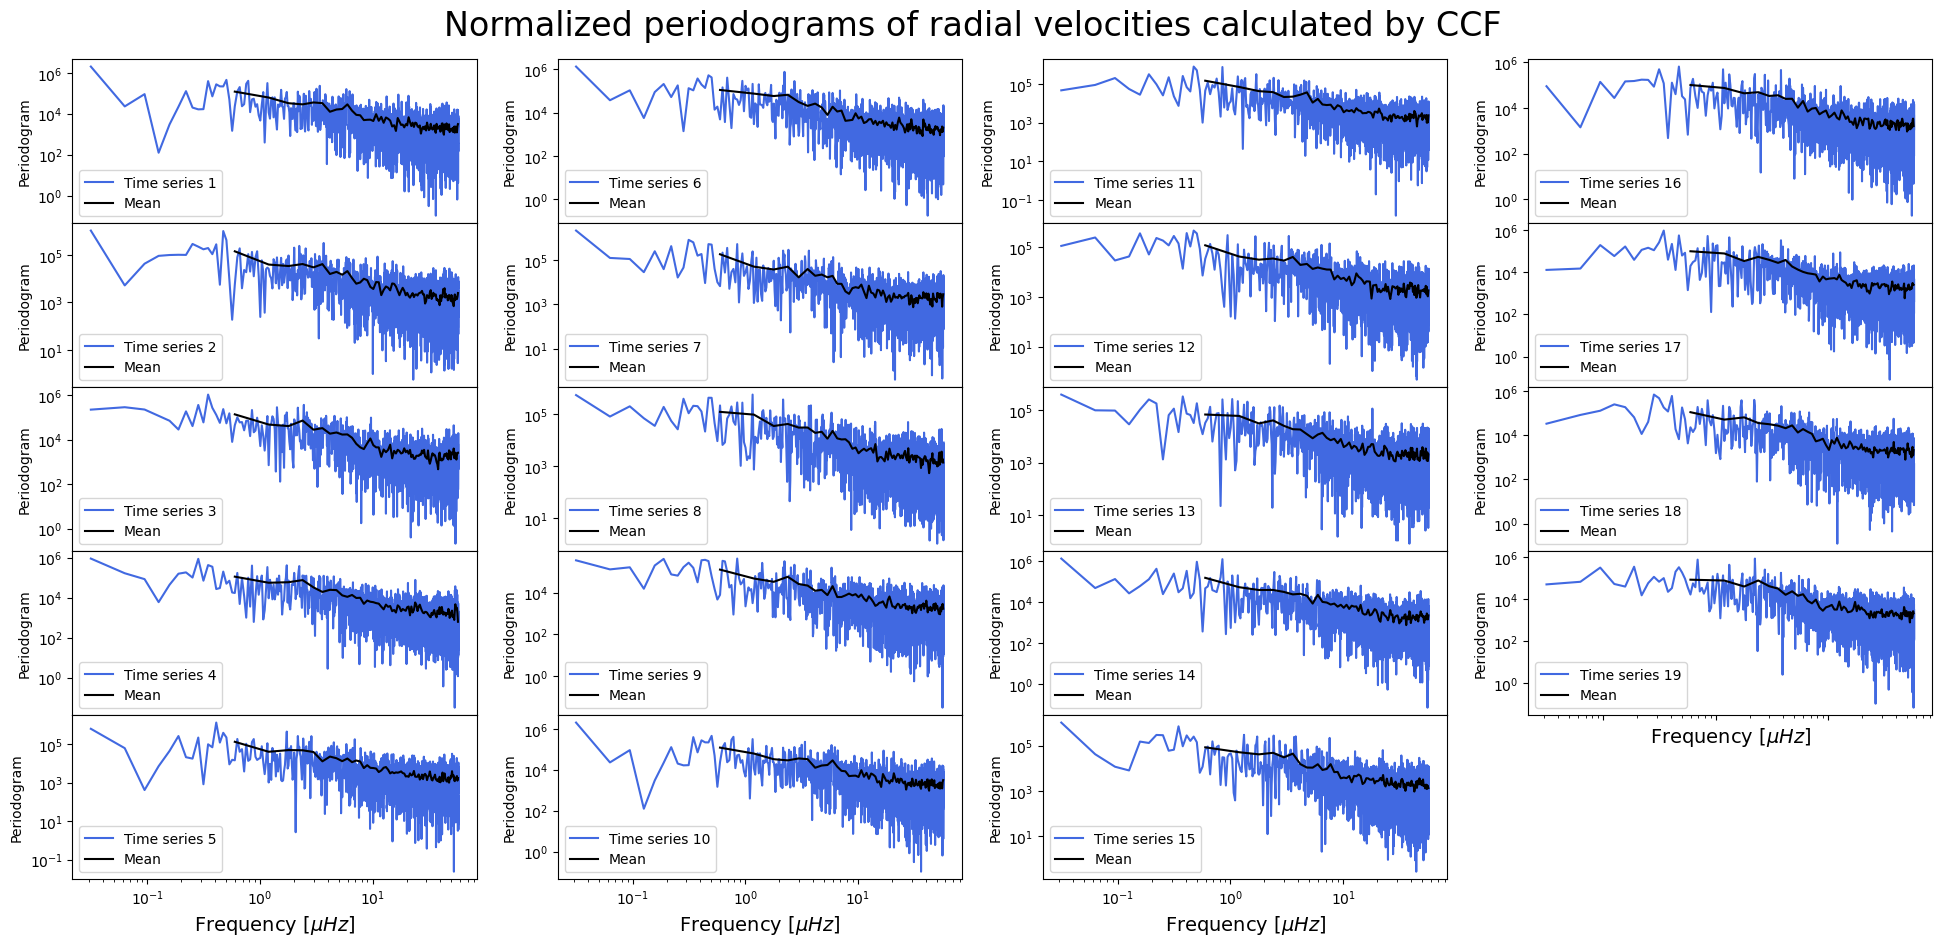

In [38]:
# plot mean periodograms
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('Normalized periodograms of radial velocities calculated by CCF', size=24)

r = 0
k = -1
norm = dt / len(times)  # same timestape for all techniques, so same normalization

for i in range(N_files):  # iterate over the 19 time series of spectra
    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row
    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][k].set_xlabel(r'Frequency [$\mu Hz$]', size=14)
    axs[r][k].loglog(freq_hz[mask] * 10**6, power_specs[i][mask], color='royalblue', label=f'Time series {i+1}')  # original periodogram
    axs[r][k].loglog(f_hz * 10**6, psd_ccf[i], color='k', label='Mean')  # mean periodogram
    axs[r][k].set_ylabel('Periodogram', size=10)
    axs[r][k].legend()
    r += 1  # advance to the next row

fig.delaxes(axs[-1][-1])  # take out extra subplot
axs[-2][-1].set_xlabel(r'Frequency [$\mu Hz$]', size=14)

#xticks = axs[-1][-2].get_xticks()[1:]
#axs[-2][-1].set_xticks(xticks)
#axs[-2][-1].set_xticklabels([str(int(i)) for i in xticks])

plt.subplots_adjust(hspace=0, top=.93)
plt.show()

### Harvey fit

In [54]:
params = []
count = 1
for i in psd_ccf:
    # initial guess
    p0 = [
        sum(i) * df_hz,                  # a -> total power
        5 / 10**6,                     # b -> turnover frequency from the plot above (where the power starts to decay)
        2.0,                             # c -> classical value
        np.median(i[f_hz * 10**6 > 20])  # d -> median of the noisy part from the plot above
    ]

    # fit
    try:
        p, _ = curve_fit(t.harvey, f_hz[1:], i[1:], p0=p0)
        p_dict = {'a': p[0], 'b': p[1], 'c': p[2], 'd': p[3]}
        params.append(p_dict)
    except Exception as e:
        print(f'Error with spectrum number {count}:')
        print(e)
        params.append({'a': np.nan, 'b': np.nan, 'c': np.nan, 'd': np.nan})
    count += 1

a = [i['a'] for i in params]
b = [i['b'] for i in params]
c = [i['c'] for i in params]
d = [i['d'] for i in params]

Error with spectrum number 8:
Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


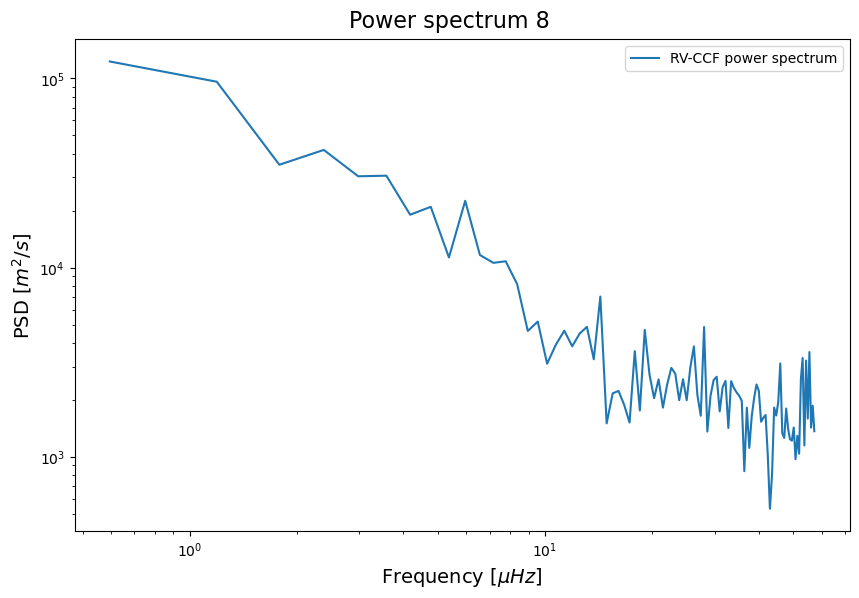

In [58]:
# show problematic PSD
i = 7
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Power spectrum {i+1}', size=16)

ax.loglog(f_hz * 10**6, psd_ccf[i], label='RV-CCF power spectrum')
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel(r'PSD [$m^2 / s$]', size=14)
ax.legend()

plt.subplots_adjust(top=.93)
plt.show()

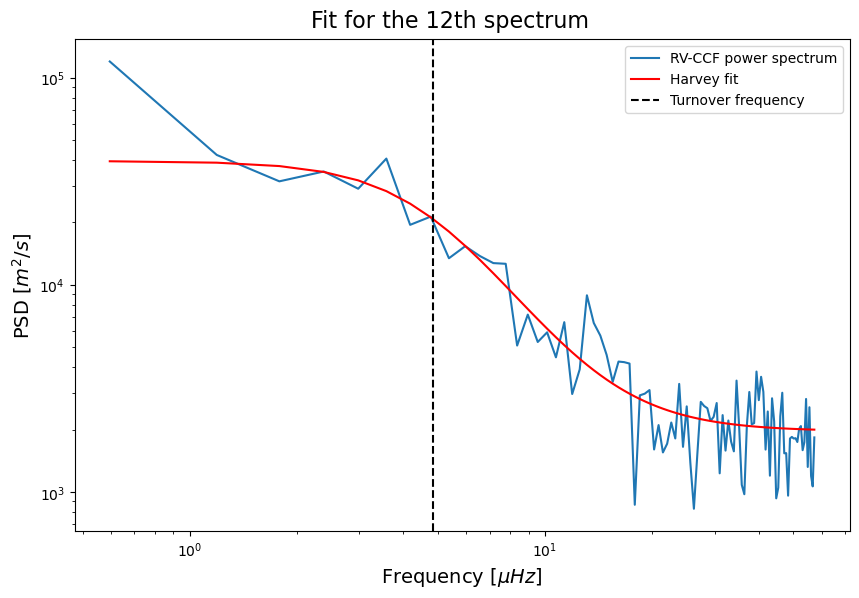

In [46]:
# plot fit
i = 11
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Fit for the {i+1}th spectrum', size=16)

ax.loglog(f_hz * 10**6, psd_ccf[i], label='RV-CCF power spectrum')
ax.loglog(f_hz * 10**6, t.harvey(f_hz, a[i], b[i], c[i], d[i]), label='Harvey fit', color='red')
ax.axvline(b[i] * 10**6, color='k', linestyle='--', label='Turnover frequency')
ax.set_xlabel(r'Frequency [$\mu Hz$]', size=14)
ax.set_ylabel(r'PSD [$m^2 / s$]', size=14)
ax.legend()

plt.subplots_adjust(top=.93)
plt.show()

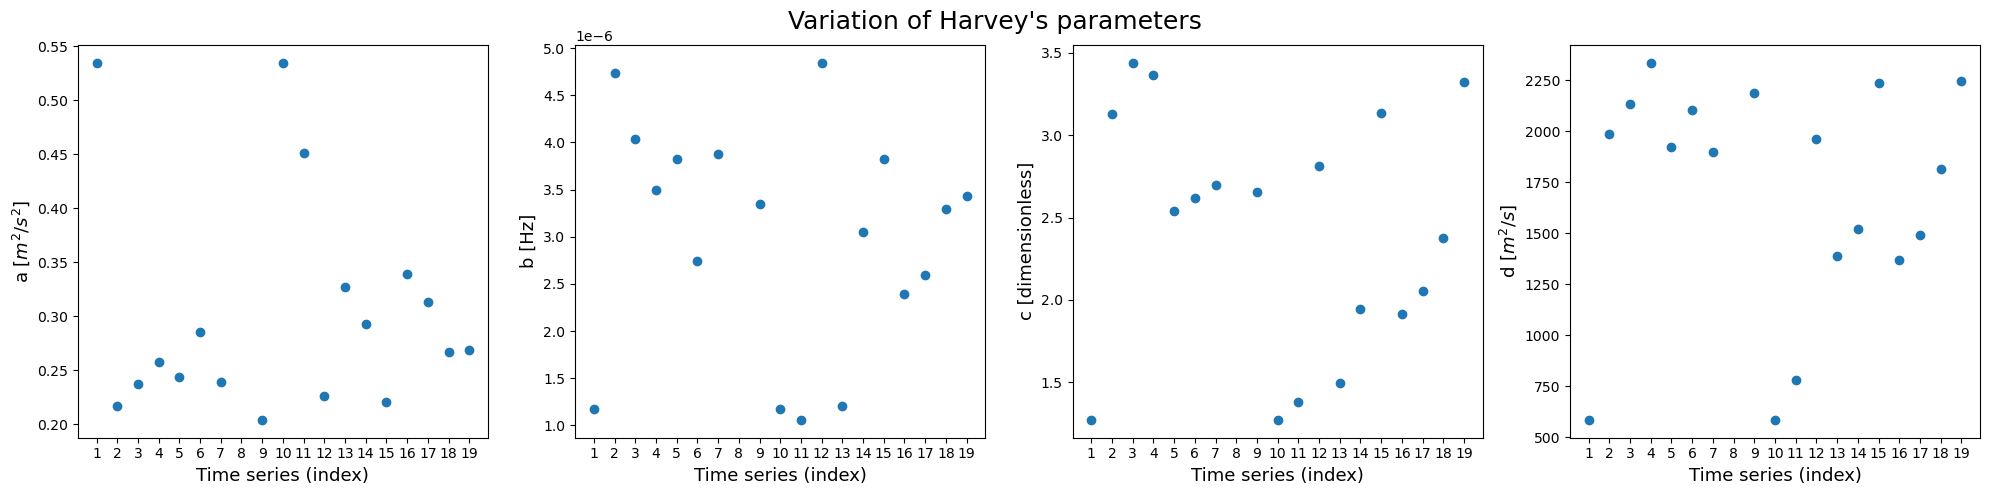

In [49]:
x = np.arange(1, N_files + 1, 1)

fig, axs = plt.subplots(1, 4, figsize=(20, 5), sharex=True)
fig.suptitle("Variation of Harvey's parameters", size=18)

axs[0].scatter(x, a)
axs[0].set_xlabel('Time series (index)', size=13)
axs[0].set_ylabel(r'a [$m^2/s^2$]', size=13)
axs[0].set_xticks(x)

axs[1].scatter(x, b)
axs[1].set_xlabel('Time series (index)', size=13)
axs[1].set_ylabel('b [Hz]', size=13)

axs[2].scatter(x, c)
axs[2].set_xlabel('Time series (index)', size=13)
axs[2].set_ylabel('c [dimensionless]', size=13)

axs[3].scatter(x, d)
axs[3].set_xlabel('Time series (index)', size=13)
axs[3].set_ylabel(r'd [$m^2/s$]', size=13)

fig.tight_layout()
plt.subplots_adjust(top=.91)
plt.show()

## Apply PCA

In [19]:
# corrected wavelength
lambda_corr = np.array([t.calculate_lambda_corr(wl, i) for i in rv_ccf])  # list of N_files matrices, for which each row contains a list of corrected wavelengths for a certain RV value

In [20]:
lambda_corr.shape

(19, 3686, 122)

In [21]:
data_spectra.shape

(19, 3686, 122)

In [22]:
# interpolation to a common reference grid, as lambda_corr is different for each spectrum

spectra_list = []  # list of N_files spectra matrices

for i in range(N_files):
    resampled_flux = []
    for wave, flux in zip(lambda_corr[i], data_spectra[i]):  # iterate over wavelength, spectrum pairs
        interp_flux = np.interp(wl, wave, flux)  # interpolate the observed spectrum into the reference grid
        resampled_flux.append(interp_flux)  # save
    spectra_list.append(np.array(resampled_flux))

spectra_list = np.array(spectra_list)

In [23]:
# apply double centering to each spectra matrix
spectra_centered = np.array([t.double_centering(i) for i in spectra_list])

In [24]:
# apply PCA to the centered spectra matrix
n_components = 20

pcs_ts = []  # list of N_files lists of of principal components
for i in spectra_centered:  # each is is a double-centered matrix
    pca_flux = PCA(n_components=n_components)  # create PCA object
    pcs_ts.append(pca_flux.fit_transform(i))  # fit the model with spectra_centered and apply the dimensionality reduction
pcs_ts = np.array(pcs_ts)

In [25]:
# component significance
# multiple realizations allow to calculate error bars
n_realizations = 20
snr = 2000000
sigma = 1 / snr
mean_maxes = np.array([t.calculate_pca_significance(n_realizations, n_components, i, sigma, bar=False) for i in spectra_centered])  # list of max mean and std for each PC: [(max_avg_1, max_std_1), (max_avg_2, max_std_2), ..., (max_avg_n, max_std_n)]

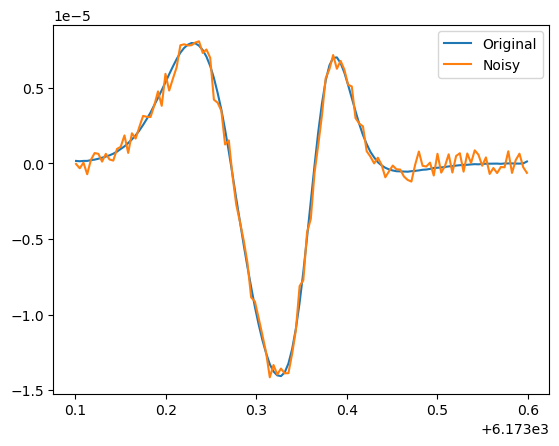

In [26]:
# show noise
spectra_noisy = np.array([i + np.random.normal(0, sigma, len(wl)) for i in spectra_centered])  # add gaussian noise to the original data
plt.plot(wl, spectra_centered[0][0], label='Original')
plt.plot(wl, spectra_noisy[0][0], label='Noisy')
plt.legend()
plt.show()

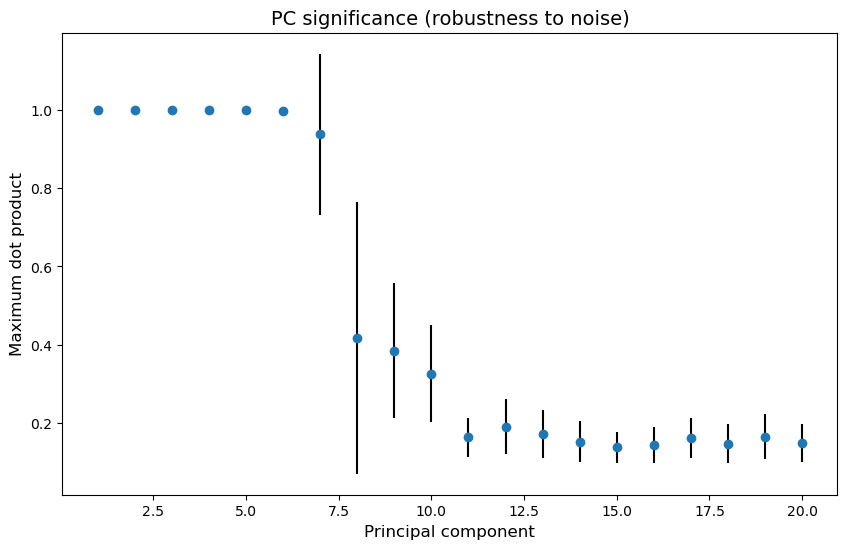

In [27]:
# plot component significance
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(np.linspace(1, n_components, n_components), mean_maxes[0][:, 0], mean_maxes[0][:, 1], fmt='o', ecolor='k')
ax.set_title('PC significance (robustness to noise)', size=14)
ax.set_xlabel('Principal component', size=12)
ax.set_ylabel('Maximum dot product', size=12)
plt.show()

In [28]:
# calculate power spectrum
dt = times[1] - times[0]
file = 0  # pick one file to show components
pcs = pcs_ts[file]

# power spectrum
sp = np.array([np.fft.fft(pcs[:, i]) for i in range(n_components)])
power = np.abs(sp)**2

# calculate frequencies
# using fftfreq
freq = np.array([np.fft.fftfreq(pcs[:, i].shape[0], dt) for i in range(n_components)])

# by hand
N = len(times)
df = 1 / (N * dt)
freq2 = np.array([
    k * df if k < N//2 else (k - N) * df  # second half of the list goes negative
    for k in range(N)
])

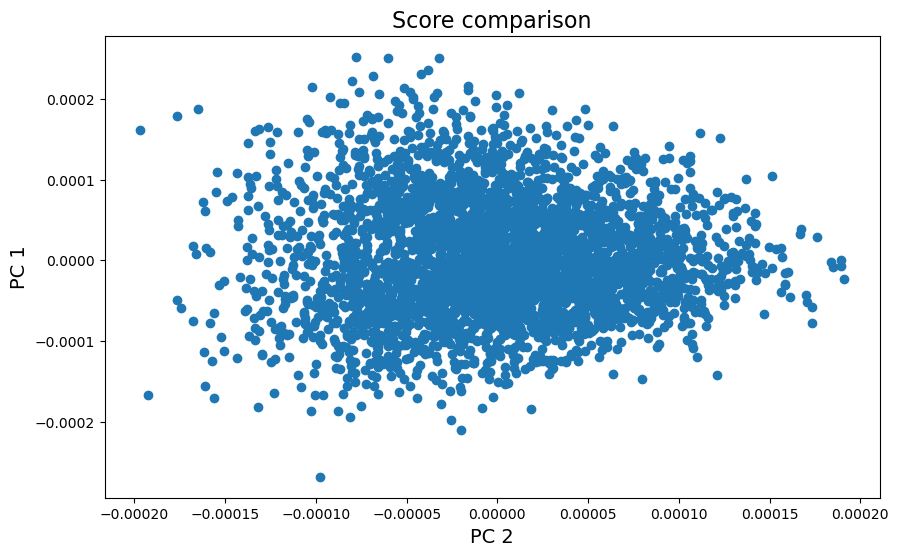

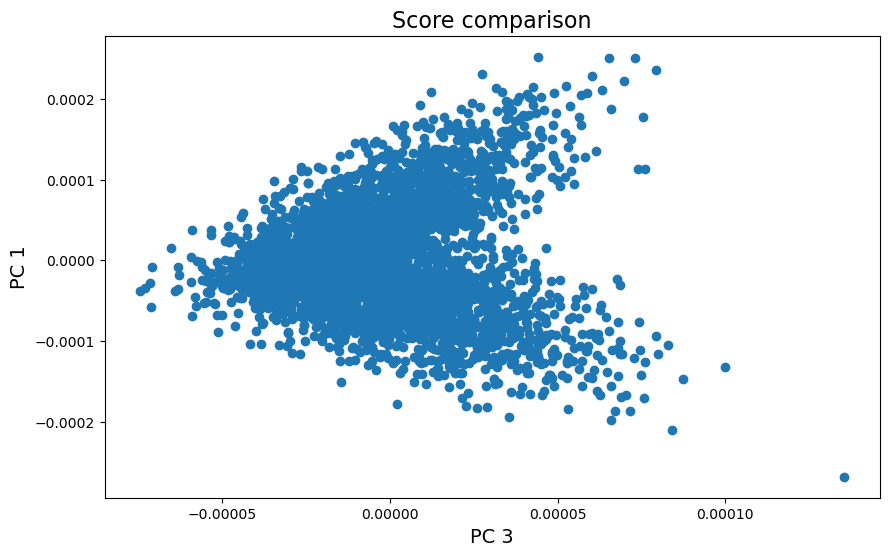

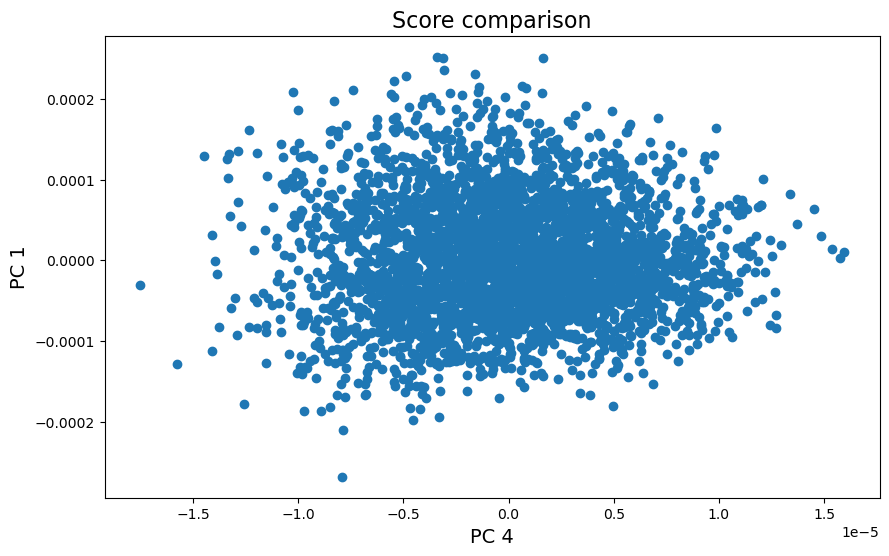

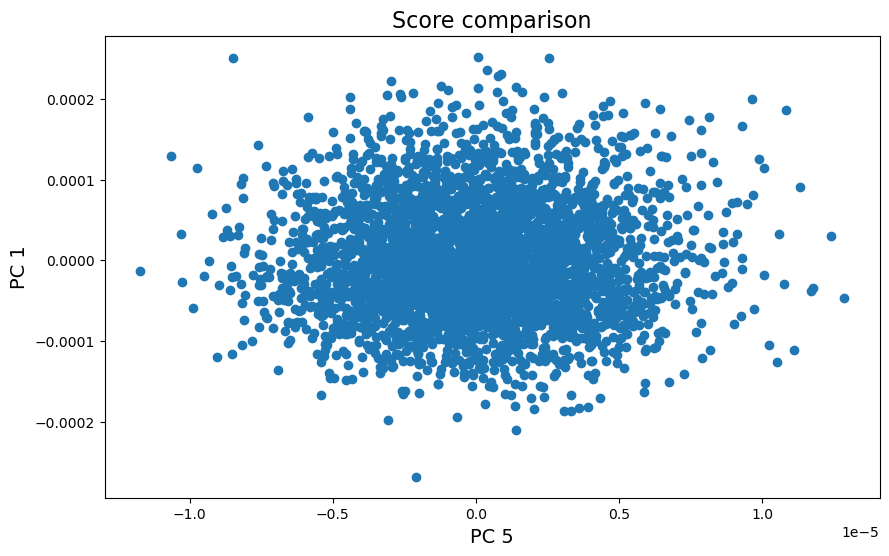

In [29]:
for i in range(1, 5):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(pcs[:, i], pcs[:, 0])
    ax.set_xlabel(f'PC {i + 1}', size=14)
    ax.set_ylabel('PC 1', size=14)
    ax.set_title('Score comparison', size=16)

    plt.show()

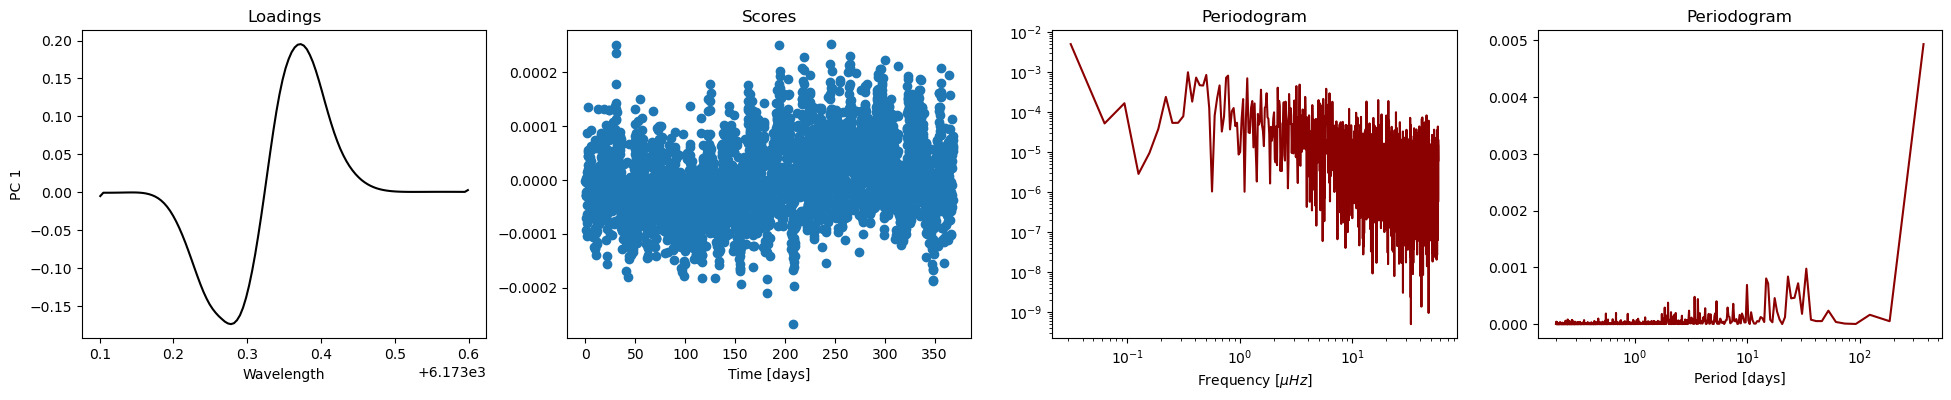

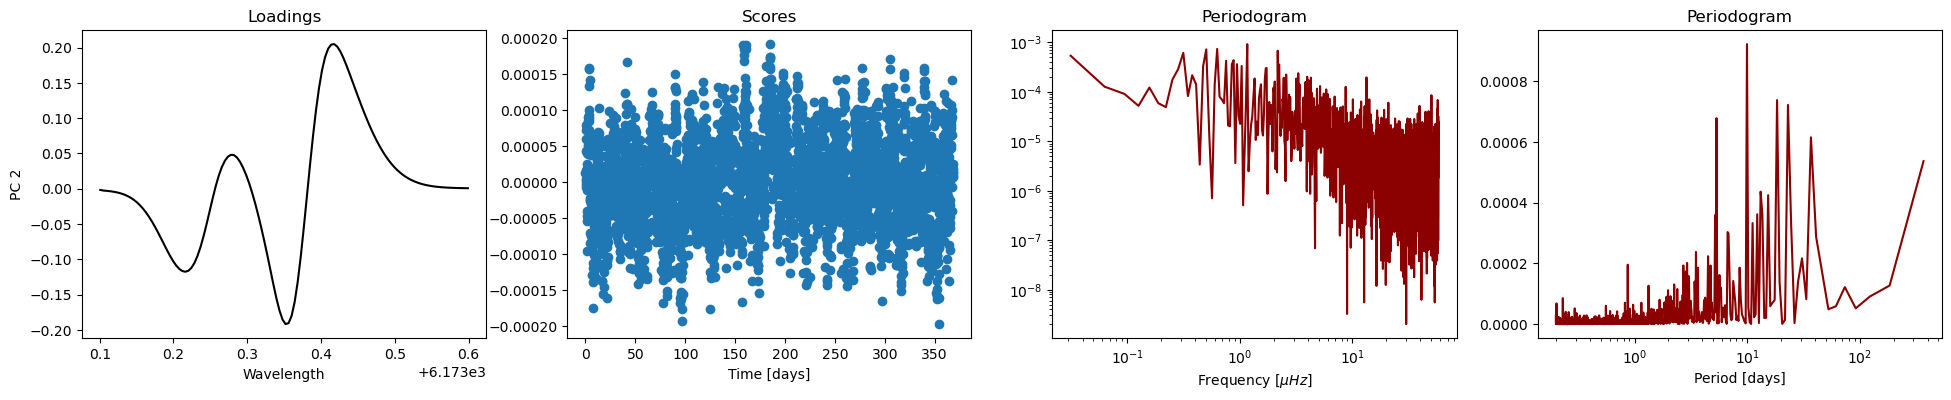

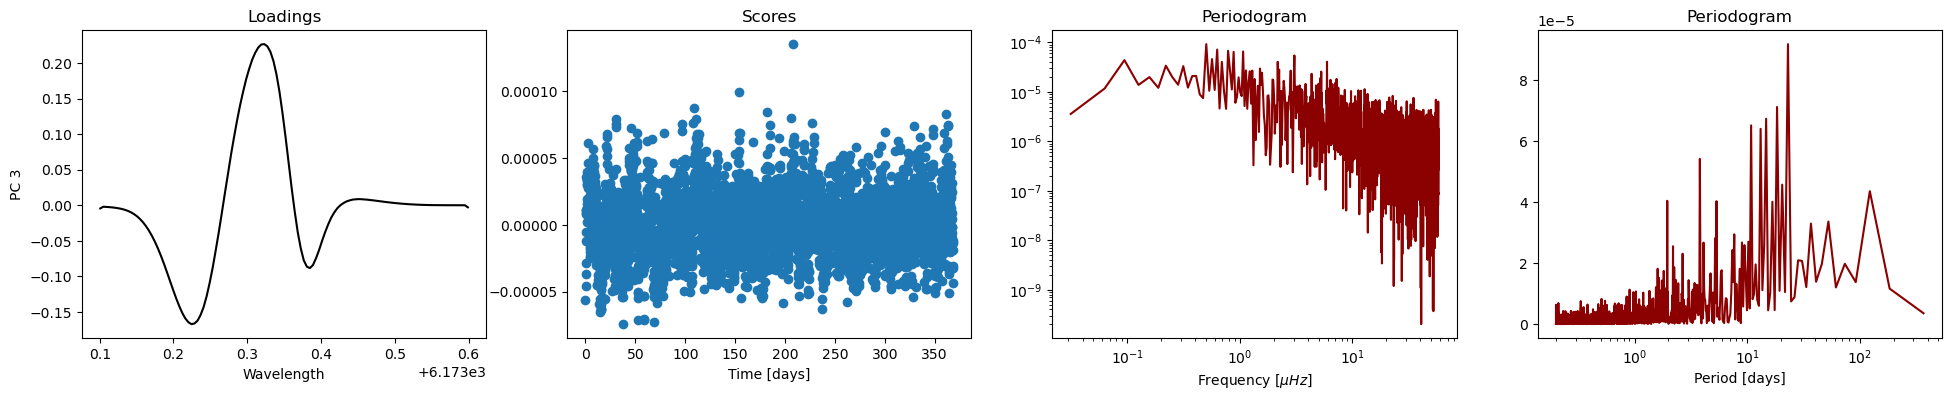

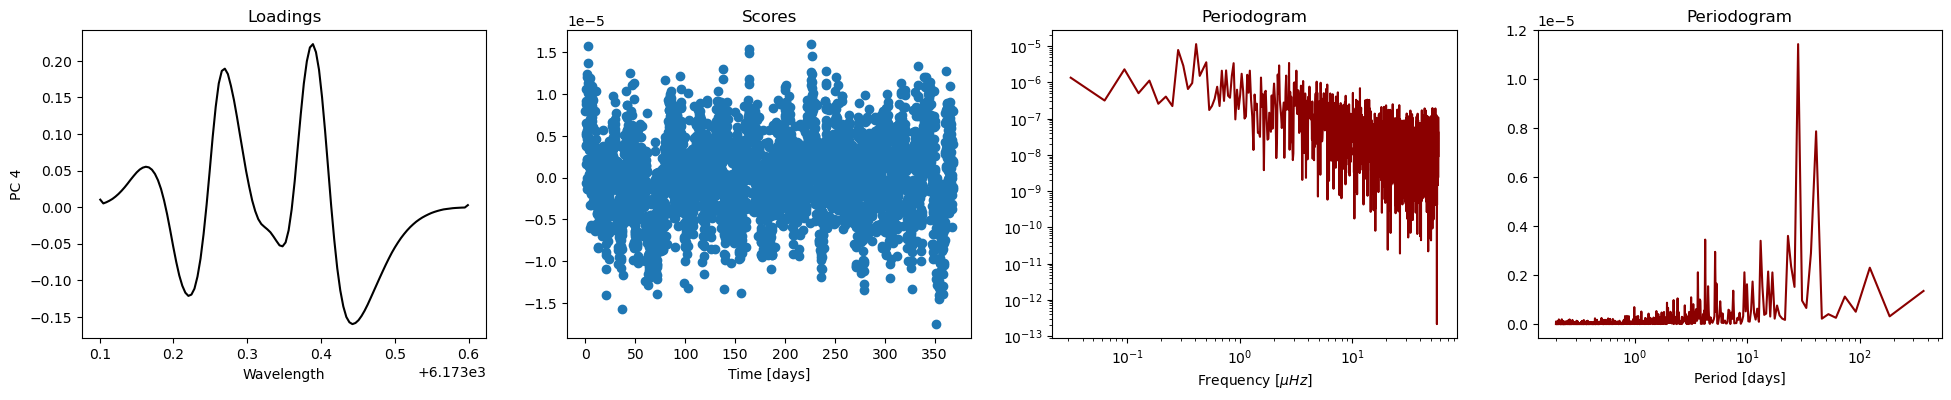

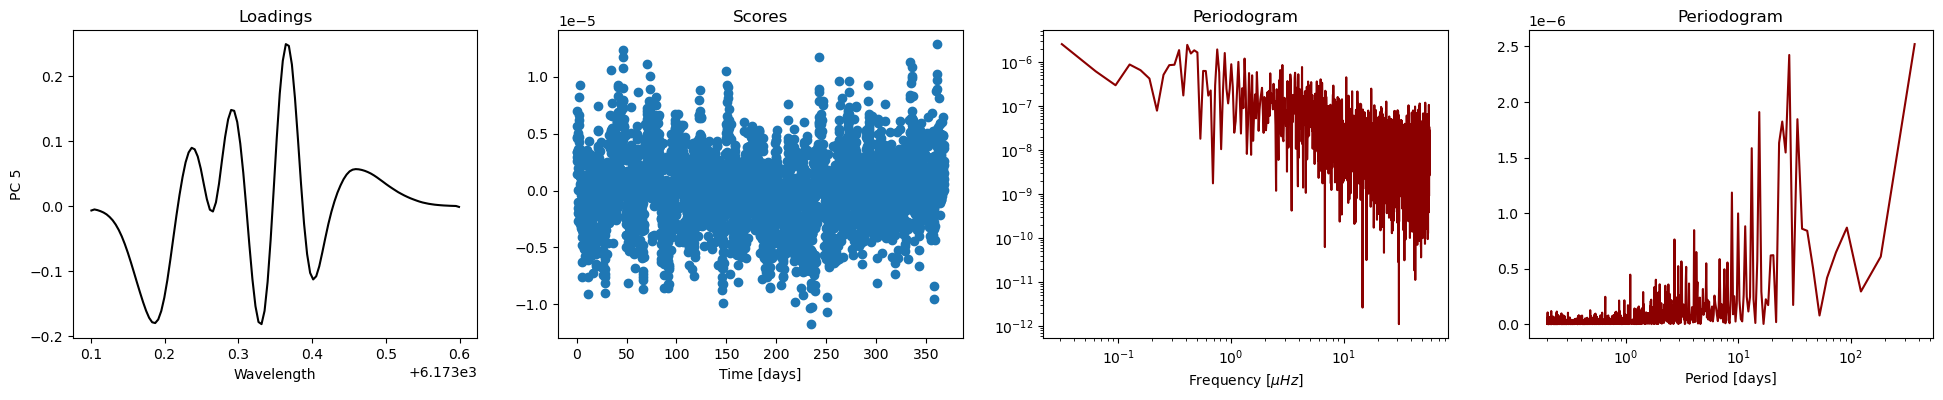

In [ ]:
# plot
for i in range(5):
    fig, axs = plt.subplots(1, 4, figsize=(24, 4))
    
    # Loadings
    axs[0].plot(wl, pca_flux.components_[i], color='k')
    axs[0].set_title('Loadings', size=12)
    axs[0].set_xlabel('Wavelength')
    axs[0].set_ylabel(f'PC {i + 1}')
    
    # Scores
    axs[1].scatter(times, pcs[:, i])
    axs[1].set_title('Scores', size=12)
    axs[1].set_xlabel('Time [days]')

    # Fourier power spectrum (frequency)
    mask = freq[i] > 0
    axs[2].plot(freq[i][mask] / 86400 * 10**6, power[i][mask], color='darkred')  # frequency divided by 86400 to pass from days^-1 to Hz, then multiplied by 10^6 to pass to microhertz
    axs[2].set_yscale('log')
    axs[2].set_xscale('log')
    axs[2].set_title('Periodogram 1', size=12)
    axs[2].set_xlabel(r'Frequency [$\mu Hz$]')
    
    # Fourier periodogram (period)
    axs[3].plot(1 / freq[i][mask], power[i][mask], color='darkred')
    #axs[3].set_yscale('log')
    axs[3].set_xscale('log')
    axs[3].set_title('Periodogram 2', size=12)
    axs[3].set_xlabel('Period [days]')

    plt.show()